# Phase 2 - Part A: Clustering

**Course:** SWE485 (Selected Topics in Software Engineering)
**Phase:** 2 (Unsupervised Learning)

## 1. Data Preparation 

### 1.1 Feature Scaling
Feature scaling is important in clustering because most clustering algorithms rely on distance calculations to measure similarity between data points. When variables are measured on different scales, features with larger numerical ranges can dominate the distance computation, leading to biased clustering results. For example, a variable such as RestingBP may have larger values compared to Oldpeak, causing it to have a disproportionate influence on cluster formation if not scaled.

Applying feature scaling ensures that all numerical variables contribute equally to the clustering process, allowing clusters to reflect meaningful patterns in the data rather than differences in measurement scale.
In this study, feature scaling was applied during preprocessing done in the EDA phase to continuous variables, including Age, MaxHR, Oldpeak, and RestingBP.

### 1.2 Target Removal

Target removal is necessary in clustering because it is an unsupervised learning task. This means the model should discover patterns and group similar data points without using any predefined labels.
Including the target variable may introduce bias into the clustering results, as it would indirectly guide the model toward known outcomes instead of uncovering natural structures in the data.

### Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.patches as mpatches
import seaborn as sns 
import numpy as np
import warnings
from sklearn.metrics import classification_report
from random import sample
from sklearn.neighbors import NearestNeighbors
from numpy.random import uniform
from scipy.spatial.distance import pdist

  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [23 lines of output]
      Traceback (most recent call last):
        File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
          ~~~~^^
        File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ~~~~^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 143, in get_requires_for_build_wheel
      

Defaulting to user installation because normal site-packages is not writeable
  Using cached pyclustertend-1.6.2-py3-none-any.whl.metadata (3.3 kB)
  Using cached numpy-1.26.4.tar.gz (15.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): still running...
  Preparing metadata (pyproject.toml): still running...
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached pandas-1.5.3.tar.gz (5.2 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error

  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [23 lines of output]
      Traceback (most recent call last):
        File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
          ~~~~^^
        File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ~~~~^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 143, in get_requires_for_build_wheel
      

Defaulting to user installation because normal site-packages is not writeable
  Using cached pyclustertend-1.6.2-py3-none-any.whl.metadata (3.3 kB)
  Using cached numpy-1.26.4.tar.gz (15.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): still running...
  Preparing metadata (pyproject.toml): still running...
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached pandas-1.5.3.tar.gz (5.2 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error

### Load Preprocessed Dataset & Remove Target

In [2]:
# Load dataset including target from supervised lerning phase
DATA_PATH = "Dataset/preprocessed_heart_data.csv"
original_data = pd.read_csv(DATA_PATH)

print(f"Dataset (with target): {original_data.shape}")

# Remove target column for clustering (unsupervised learning)
clustering_data = original_data.drop(columns=["HeartDisease"])

print(f"Clustering data shape: {clustering_data.shape}")
clustering_data.head()

Dataset (with target): (917, 21)
Clustering data shape: (917, 20)


,Age,Sex,RestingBP,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,Chol_category_Desirable,Chol_category_Borderline High,Chol_category_High
0,-1.432206,1,0.5,0,1.383339,0,-0.400000,0,1,0,0,0,1,0,0,0,1,0,0,1
1,-0.478057,0,1.5,0,0.754736,0,0.266667,0,0,1,0,0,1,0,0,1,0,1,0,0
2,-1.750256,1,0.0,0,-1.523953,0,-0.400000,0,1,0,0,0,0,1,0,0,1,0,0,1
3,-0.584074,0,0.4,0,-1.131075,1,0.600000,1,0,0,0,0,1,0,0,1,0,0,1,0
4,0.052026,1,1.0,0,-0.581047,0,-0.400000,0,0,1,0,0,1,0,0,0,1,1,0,0


## 2. Ability of Data to be Clustered

This section examines the clusterability of the dataset in order to better contextualize the observed clustering outcomes. Following the data preprocessing stage, preliminary evaluations of both models indicated limited cluster structure, as reflected by an unclear elbow pattern in the K-Means method and a high proportion of noise identified by HDBSCAN (see Section 3 for the evaluation of each model). Despite relying on fundamentally different clustering paradigms K-Means as a centroid-based approach and HDBSCAN as a density-based method, both techniques revealed similar challenges in identifying well-defined clusters. This consistency suggests that the difficulty arises from the intrinsic characteristics of the dataset rather than the choice of algorithm.

Our investigation consists of three complementary steps to assess the clusterability of the dataset:

**The Hopkins Statistic** , which quantifies the tendency of the data to form clusters

**Visual Assessment of Tendency (VAT)** , which provides a visual representation of potential cluster structure

**Pairwise Distance Distribution** , which examines the distribution of distances between data points to assess whether the data forms distinct groups or follows a continuous structure

### **Step 1. Hopkins statistic**

The Hopkins statistic is a numerical measure used to quantify the clustering tendency of a dataset and is commonly applied as a preliminary step before clustering. It is based on comparing the distances of real data points to their nearest neighbors with the distances of randomly generated points within the same data space. If the dataset contains meaningful structure, real points tend to lie closer to each other than random points, indicating clustering tendency. In contrast, if both distances are similar, the data is considered close to randomly distributed, suggesting a lack of inherent cluster structure.

Interpretation:
- ≈ 0.5 → Random distribution (i.e., no meaningful clusters).
- → 1 → Strong clustering tendency.
- \> 0.75 → Clustering tendency at the 90% confidence level.

In [16]:
# function to compute hopkins's statistic for the dataframe X
def hopkins_statistic(X):
    
    X=X.values  #convert dataframe to a numpy array
    sample_size = int(X.shape[0]*0.1) #0.05 (5%-10%) based on paper by Lawson and Jures
    
    
    #a uniform random sample in the original data space
    X_uniform_random_sample = uniform(X.min(axis=0), X.max(axis=0) ,(sample_size , X.shape[1]))
    
    
    #a random sample of size sample_size from the original data X
    random_indices=sample(range(0, X.shape[0], 1), sample_size)
    X_sample = X[random_indices]

    
    #initialise unsupervised learner for implementing neighbor searches
    neigh = NearestNeighbors(n_neighbors=2)
    nbrs=neigh.fit(X)
    
    #u_distances = nearest neighbour distances from uniform random sample
    u_distances , u_indices = nbrs.kneighbors(X_uniform_random_sample , n_neighbors=2)
    u_distances = u_distances[: , 0] #distance to the first (nearest) neighbour
    
    #w_distances = nearest neighbour distances from a sample of points from original data X
    w_distances , w_indices = nbrs.kneighbors(X_sample , n_neighbors=2)
    #distance to the second nearest neighbour (as the first neighbour will be the point itself, with distance = 0)
    w_distances = w_distances[: , 1]
    
    u_sum = np.sum(u_distances)
    w_sum = np.sum(w_distances)
    
    #compute and return hopkins' statistic
    H = u_sum/ (u_sum + w_sum)
    return H

# The Hopkins statistic is calculated multiple times to account for randomness in sampling,
# and the average value is used to provide a more reliable estimate of clusterability
sum=0
for i in range(5):
    H=hopkins_statistic(clustering_data)
    sum += H
avg_hopkins = sum / 5
print(f"Average Hopkins Statistic: {avg_hopkins:.2f}")

Average Hopkins Statistic: 0.67


In our case, the Hopkins statistic yielded a value of approximately 0.67, which falls between 0.5 and 0.75, indicating a moderate clustering tendency (below the 90% confidence level). While this suggests that the data is not purely random, it does not provide sufficient evidence of well-defined or well-separated clusters. This limitation is supported by prior work, which shows that relying solely on the Hopkins statistic may lead to misleading conclusions about clusterability, as it does not capture the shape, separation, or overlap of potential clusters (A Comprehensive Evaluation of Clustering Tendency Measures, 2025).

Therefore, Visual Assessment of Tendency (VAT) was employed as a complementary step to visually examine the presence and clarity of cluster structure. In addition, the pairwise distance distribution was analyzed to understand how close or far the data points are from each other. Taken together, these methods provide a more comprehensive and reliable assessment of clusterability.


> A Comprehensive Evaluation of Clustering Tendency Measures. (2025). arXiv preprint. https://arxiv.org/pdf/2512.03070

### **Step 2. Visual Assessment of Tendency (VAT)**


The VAT approach assesses clustering tendency by visualizing pairwise dissimilarities as a reordered distance matrix. It rearranges data points so that similar observations are placed next to each other, revealing potential cluster structures as dark block-like patterns along the diagonal (Bezdek & Hathaway, 2002). In well-clustered data, clear and distinct dark square blocks appear along the diagonal, representing compact and well-separated clusters. In contrast, a diffused, interleaved, or noisy pattern without clear block structures indicates weak or absent cluster tendency, where no meaningful grouping exists.

In [ ]:
from pyclustertend import vat

plt.figure(figsize=(2, 2))
vat(clustering_data.values)
plt.title("Figure (1): VAT Diagram")
plt.show()

ModuleNotFoundError: No module named 'pyclustertend'


The VAT diagram in Figure (1) shows a highly interleaved and diffused pattern, lacking the block-diagonal structure typically observed in well-separated data. This suggests that the dataset lacks a strong clustering tendency (Bezdek & Hathaway, 2002). This observation helps explain the relatively weak performance of the clustering models, as the absence of clear structure makes it difficult for algorithms to identify meaningful and well-separated clusters. To further support this observation and provide additional confirmation from a different perspective, the pairwise distance distribution was analyzed.

> Bezdek, J. C., & Hathaway, R. J. (2002). VAT: A visualization tool for cluster tendency assessment. In Proceedings of the International Conference on Neural Information Processing (pp. 79–83).


### **Step 3. Pairwise Distance Distribution**

The Pairwise Distance Distribution serves as diagnostic tool for the inherent potential of a dataset to be divided into meaningful groups by revealing the intrinsic geometric structure (the natural way data points are positioned relative to each other). This distribution provides an algorithm-agnostic view, meaning it offers a perspective independent of any specific method or software used later, focusing purely on how data points relate within the feature space. In a clusterable dataset, the distribution typically exhibits multimodality (the appearance of multiple peaks in the graph). A primary peak represents small intra-cluster distances (distances between points within the same group), while subsequent peaks represent larger inter-cluster distances (the gaps between different groups). In contrast, a unimodal distribution which is a graph with only one single, smooth peak suggests a continuous or uniform structure, indicating a lack of natural separation (Jain & Dubes, 1988).

> Jain, A. K., & Dubes, R. C. (1988). Algorithms for clustering data. Prentice-Hall, Inc.

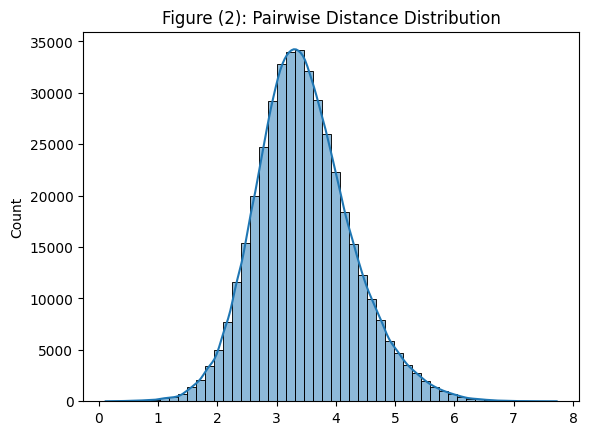

In [294]:
# Compute distances
distances = pdist(clustering_data)

# Plot
sns.histplot(distances, bins=50, kde=True)
plt.title("Figure (2): Pairwise Distance Distribution")
plt.show()

The pairwise distance distribution in Figure (2) shows a clear unimodal, smooth bell-shaped pattern, indicating that distances between observations arise from a single underlying distribution. This indicates weak intrinsic clusterability, meaning that any clusters identified by algorithms are likely to be artificial rather than reflecting true underlying structure. Since the analysis was conducted on appropriately scaled features, the observed unimodal pattern reflects the true distribution of the data in the feature space, rather than being an artifact of preprocessing. This analysis is independent of the clustering algorithm, as it reflects the intrinsic structure of the dataset rather than the behavior of a specific method.



### Conclusion

The results indicate weak clusterability in the dataset. The unimodal pairwise distance distribution in figure (2), the moderate Hopkins statistic (≈ 0.67), and the lack of clear structure in the VAT visualization in figure (1) collectively suggest that the data does not naturally form well-separated clusters. Nevertheless, the selected clustering algorithms will still be applied for exploratory and educational purposes.

---

# The Clustering Model Templates Overview




## Section 1. Clustering Rationale & Algorithm Selection
In this section, we justify the selection of each clustering algorithm by considering several key factors, including the size of the dataset and the types of features involved, the expected shapes and structures of the clusters, as well as the scalability of the algorithm and the interpretability of its results.



## Section 2. Cluster Determination & Implementation
In this section, we apply two clustering algorithms. For each algorithm, we first determine the optimal number of clusters, and then perform clustering to assign cluster labels accordingly.




## Section 3. Evaluation Metrics & Visualizations

In this section, we evaluate the clustering results using suitable metrics for each algorithm, each providing a different perspective on cluster quality. These evaluation measures help assess how well the clusters are separated, how compact they are, and how meaningful the overall structure is. In addition, we provide visual interpretations of the clusters by projecting them into lower-dimensional space using PCA or t-SNE for better understanding. We also examine feature importance within each cluster to identify the characteristics that distinguish them, along with analyzing the distribution of cluster sizes to gain insight into the balance and representativeness of the formed groups. 

### 3.1 Evaluation Metrics

The following provides definitions, interpretations, appropriate usage, and drawbacks for each selected metric. However, the descriptions are not exhaustive and focus only on the aspects most relevant to our analysis.

#### **DBCV (Density-based clusters validation)**
   - **Definition** Evaluates clustering quality based on density sparseness within clusters and density separation between clusters, using density connectivity rather than Euclidean distance. Considers both density and shape properties of clusters(Moulavi et al., 2014).
   - **Interpretation**:
      * A value near +1 indicates strong, well-separated density regions.
      * A value close to 0 indicates ambiguous clustering.
      * A value close to −1 signals poor or overlapping clusters.
   - **Appropriate for:** Ideal for density-based algorithms like HDBSCAN or DBSCAN, especially when clusters are irregular in shape, varying cluster densities, or when noise points are present.
   - **Drawbacks:** Computationally intensive due to MST (minimal spanning tree) construction, and it may perform poorly when there is only one cluster or when all points are considered noise (Moulavi et al., 2014). Additionally, it may be less informative for centroid-based clustering methods.

#### **WCSS (Within-Cluster Sum of Squares)** 
   - **Definition**  Measures the sum of squared distances between each point and its cluster centroid.
   - **Interpretation**: Lower WCSS implies compact, homogeneous clusters.
   - **Appropriate for:** Effective for centroid-based algorithms like k-means, where clusters are roughly spherical.
   - **Drawbacks:** Not suitable for density-based algorithms, as centroids may not represent complex or irregular cluster shapes. Also it bias with the increasing in number of clusters .(scikit-learn, n.d.)

#### **The Silhouette Score** 
   - **Definition** Compares a data point’s average distance to other points within its own cluster (intra-cluster distance) with its distance to the nearest neighboring cluster (inter-cluster distance). The overall Silhouette Score is computed as the mean of the Silhouette Coefficient across all samples.
   - **Interpretation**: Ranges from -1 to +1.
      * A score near +1 indicates the point is far from neighboring clusters.
      * A score near 0 indicates overlapping clusters.
      * A score near −1 indicates the point may be assigned to the wrong cluster.
   - **Appropriate for:** Commonly used for evaluating centroid-based algorithms such as k-means, where clusters are relatively convex and well-separated. However, it is less meaningful for density-based or irregular clusters where distances vary widely.
   - **Drawbacks:** Computationally expensive (O(n²)) and performs poorly on density-based shapes. It gives lower results for irregularly shaped clusters, even if the clustering is optimal. (scikit-learn, n.d.)


#### **Davies-Bouldin Index** 
   - **Definition** Measures how similar clusters are to each other based on their compactness (size) and the distance between them.
   - **Interpretation**
      *  Lower values (closer to 0) indicate compact, well-separated clusters with minimal overlap.
      *  Higher values indicate that clusters are more similar to each other, suggesting poor separation and higher overlap.
      * The minimum and optimal value is zero.
   - **Appropriate for:** Useful for algorithms producing centroid-defined clusters (e.g., k-means).
   - **Drawbacks:** Performs poorly for density or shape based clusters, where centroid-based separation is not meaningful. It gives lower results for irregularly shaped clusters, even if the clustering is optimal. (scikit-learn, n.d.)


#### **B-Cubed Precision and Recall** 

- **Definition** Evaluates clustering quality by measuring precision and recall at the level of individual data points, considering the proportion of correctly assigned items within the same cluster (precision) and the proportion of true class members captured by the cluster (recall). These measures are computed for each point and then averaged over the dataset.

- **Interpretation**:  
   * High **B-Cubed Precision** indicates that clusters contain mostly data points from the same true class (low false positives).  
   * High **B-Cubed Recall** indicates that most members of a true class are grouped within the same cluster (low false negatives).  
   * High values for both suggest well-formed and meaningful clusters.

- **Appropriate for:** Suitable when ground truth labels are available, especially for evaluating clustering performance at a fine-grained level. It is particularly effective for datasets with imbalanced classes or varying cluster sizes, as it evaluates each data point individually rather than relying on global cluster properties.

- **Drawbacks:** Requires true labels, which are not always available in unsupervised settings. It can also be computationally expensive for large datasets and may be sensitive to noise or mislabeled data.

>  
>  Moulavi, D., Jaskowiak, P. A., Campello, R. J. G. B., Zimek, A., & Sander, J. (2014). Density-based clustering validation. In Proceedings of the SIAM International Conference on Data Mining (pp. 839–847).
   >
   > MetricGate. (n.d.). Density-based cluster validation. Retrieved April 28, 2026, from https://metricgate.com/docs/density-based-cluster-validation/
   >
   > scikit-learn. (n.d.). Clustering. Retrieved April 28, 2026, from https://scikit-learn.org/stable/modules/clustering.html#k-means

### 3.2 Visualizations

Most datasets contain many variables resulting in large dimensional space, making it impossible to see how points relate to one another in their raw state. By reducing the complexity of the data while preserving as much of the original variance in the structure as possible, it provides a visual sanity check for the results of the clustering algorithm.

#### **i. Principal Component Analysis (PCA)**

PCA follows a specific linear transformation process. It aims to maximize the variance, ensuring that the data can be represented in a 2D or 3D view while losing as little information as possible. This is done by projecting the data onto a lower-dimensional subspace and identifying the principal components (the directions where the data is most spread out). These directions are found by computing the eigenvectors and eigenvalues of the covariance matrix, where the eigenvectors represent the directions and the eigenvalues indicate how much variance is captured along each direction. The eigenvectors with the largest eigenvalues are selected as the principal components. By using these components as new axes (e.g., X and Y), PCA effectively captures the most significant patterns in the data, allowing for a simplified representation that still preserves the essential structure of the dataset.

#### **ii. T-distributed Stochastic Neighbor Embedding (t-SNE)** 

t-SNE is a non-linear dimensionality reduction technique designed to capture the local structure of high-dimensional data. It works by converting pairwise Euclidean distances between data points into joint probability distributions that represent similarities in the high-dimensional space. It then maps the data into a lower-dimensional space by minimizing the Kullback–Leibler (KL) divergence, meaning it attempts to preserve the same similarities between data points as in the original space. This process preserves local relationships, making t-SNE particularly effective for visualizing clusters and complex non-linear patterns. Unlike PCA, which is a linear technique that projects data onto directions of maximum variance, t-SNE focuses on preserving local neighborhood structures rather than global variance. As a result, PCA provides a more stable and interpretable transformation, while t-SNE offers better visualization of non-linear cluster structures. However, t-SNE is a stochastic algorithm, meaning that results can vary between runs unless a random seed is fixed. which can significantly affect the output. Additionally, t-SNE does not preserve global distances, making it unsuitable for measuring true relationships between clusters.

### 3.3 Feature Importance Per Cluster
Feature importance refers to identifying and ranking the features that most influence a model’s behavior. In clustering, it aims to determine which variables most influence the formation and differentiation of clusters, despite the absence of true labels. 



## Section 4. Cluster Interpretation & Profiles

In this section, we further interpret the clustering results by profiling each cluster to identify the key characteristics that define each group. This involves examining the dominant features and patterns within each cluster to understand what distinguishes one group from another. Additionally, we relate these clusters to the medical domain, explaining what each group represents in terms of patient profiles or health conditions.

## Section 5. Integration Feasibility and Justification

In this section, we discuss the feasibility of integrating clustering results into the system to enhance personalized, data-driven medical recommendations based on patient groupings. If integration is not feasible, a clear justification is provided, such as weak clustering performance or lack of meaningful clinical interpretation.

## Section 6. Challenges & Limitations

In this section, we discuss the main challenges and limitations encountered during the clustering process.

---


## **Cluatering Model 1: K-means**

## Section 1. Clustering Rationale & Algorithm Selection



### **What is K-means Algorithm?**
K-Means is a centroid-based clustering algorithm that partitions a dataset into *K* distinct clusters by minimizing the Within-Cluster Sum of Squares (WCSS). It is designed for numerical data, where similarity between data points is measured using a distance mesuare typically Euclidean distance. The algorithm aims to group similar observations together while keeping clusters as compact as possible.

### **Distance Metric**

K-Means uses Euclidean distance to measure similarity:

$$
d(x, \mu) = \sqrt{\sum_{j=1}^{n} (x_j - \mu_j)^2}
$$

- $n$ represents the total number of features.
- $x_j$ is the value of a specific feature.
- $\mu_j$ is the value of the cluster's average for that same feature.

### **How K-Means Works ?**

K-Means follows an iterative optimization process:

1. Initialize *K* cluster centroids randomly  
2. Assign each data point to the nearest centroid  
3. Update each centroid as the mean of its assigned points  
4. Repeat until convergence where cluster assignments stabilize


The algorithm minimizes the Within-Cluster Sum of Squares (WCSS):

$$
\sum_{i=1}^{k} \sum_{x \in C_i} \|x - \mu_i\|^2
$$

- \($C_i$) is cluster \(i\)  
- \($x$) is a data point  
- \($\mu_j$) is the centroid of cluster \(i\)

This objective ensures that data points within the same cluster are as close as possible to their centroid.

---

### **Why is K-Means suitable for our data?**

#### i. Dataset size & feature types

The dataset contains 917 samples and 20 features, originally combining both numerical and categorical variables. However, all categorical features were transformed using One-Hot Encoding, resulting in binary (0/1) variables. This transformation converts the dataset into a fully numerical representation, where all features wether continuous or binary can be processed within a unified distance-based measure.

Numerical features (such as age, resting blood pressure, maximum heart rate, and oldpeak) were scaled to ensure balanced contribution in distance calculations. At the same time, categorical variables (e.g., chest pain type, ECG results, ST slope, cholesterol category) are one-hot encoded and are represented as binary dimensions, preserving their informational content while making them compatible with numerical distance based algorithms. This transformation justifies the use of K-Means, which relies on Euclidean distance and requires numerical input. In our setting where continuous features capture physiological variation and binary features captures categorical distinctions, all features contribute jointly to distance computation.  Thus, both types of medical information are incorporated without requiring separate dissimilarity measures.

A key consideration is the presence of outliers in numerical features, such as Resting Blood Pressure and Oldpeak. As a centroid-based method, K-Means is sensitive to such values because cluster centers are computed using the mean (Han et al., 2011). However, unlike standard preprocessing pipelines that might employ capping or deletion of outliers, we retained extreme values to preserve potential signals of high-risk clinical pathologies. These outliers often represent the most medically significant findings and are essential for a representative clustering of patient risk.

---

#### ii. Expected cluster shapes

Cluster shape expectations depend on both the algorithm and the structure of the data. K-Means, as a centroid-based algorithm, assumes that clusters are compact and approximately spherical in the feature space, as it minimizes the Within-Cluster Sum of Squares (WCSS) using Euclidean distance (Bishop, 2006).

This assumption may be restrictive in datasets with highly irregular or non-convex structures. However, it is reasonable for the current medical dataset for several reasons. The data represents structured clinical attributes rather than spatial or image-based patterns and similar patients tend to have similar feature values across multiple dimensions. Although One-Hot Encoding increases dimensionality, the resulting binary features still contribute meaningfully to distance by separating categorical states across dimensions. This leads to clusters that reflect similarity in overall patient profiles, rather than relying on a single dominant feature.

It is important to note that medical data may exhibit some degree of overlap between patient groups. While K-Means enforces hard boundaries between clusters, the resulting partitions can still provide useful approximations of underlying patient subgroups, particularly when interpreted with awareness of this limitation. Overall, the assumption of compact clusters aligns with the nature of the dataset, where patients with similar physiological and clinical characteristics are expected to group together in a structured and interpretable manner.

---


#### iii. Scalability & Interpretability

**Scalability** refers to the ability of a clustering algorithm to efficiently handle increasing data size and dimensionality. K-Means demonstrates strong scalability due to its simple and iterative structure, where each iteration consists of assigning data points to the nearest centroid and updating centroids accordingly.

The computational complexity of K-Means is :

$$
\mathcal{O}(n \cdot k \cdot d)
$$

- \(n\) is the number of data points  
- \(k\) is the number of clusters  
- \(d\) is the number of features  

This makes K-Means highly efficient and suitable for datasets with moderate to large size.

In our case, the use of One-Hot Encoding increases the dimensionality of the dataset due to the expansion of categorical variables into multiple binary features. Despite this increase, K-Means remains scalable because:

- Binary features (0/1) are computationally inexpensive to process  
- Distance calculations remain efficient even in higher dimensions  
- The algorithm scales linearly with both data size and number of features  


**Interpretability** refers to how easily the resulting clusters can be understood and explained. In K-Means, each cluster is represented by its centroid, defined as the mean of all data points within the cluster:

$$
\mu_j = \frac{1}{|C|} \sum_{x \in C} x_j
$$

* $\mu_j$: The new center (mean) of the cluster
* $|C|$: The number of points in the cluster
* $\sum x_j$: The sum of all points in that cluster

For one-hot encoded variables, centroid values of such feature lie between 0 and 1, which can be interpreted as:
- values close to 1 → the category is dominant in the cluster  
- values close to 0 → the category is rare in the cluster  

This means each cluster is described by the average values of numerical features (e.g., Oldpeak, Resting Blood Pressure) and binary (one-hot) features, which reflects the proportion of patients belonging to each category. Overall, K-Means provides a transparent and interpretable representation of clusters, which is particularly important in medical analysis, where understanding patient group characteristics is essential for decision-making.

---

> Han, J., Kamber, M., & Pei, J. (2011). *Data Mining: Concepts and Techniques*.  
> https://www.sciencedirect.com/book/9780123814791/data-mining-concepts-and-techniques  
>
> Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer.  
> https://link.springer.com/book/10.1007/978-0-387-45528-0

---

## Section 2. Cluster Determination & Implementation

### 2.1 Sensitivity to Initialization and K-Means++ Optimization

A significant challenge in centroid-based clustering is the sensitivity to initial centroid selection. Standard algorithms often begin by selecting initial cluster centers at random, however, because the final partitions are determined iteratively from these starting points, the algorithm is prone to converging on local optima. This stochastic nature can result in unstable clusters that vary between runs or fail to capture the true underlying structure of the patient data. To resolve this instability and ensure the reproducibility of our patient subgroups, we utilize K-Means++ initialization method (Arthur & Vassilvitskii, 2007). Unlike naive random selection, K-Means++ implements a probabilistic seeding strategy designed to spread initial centroids across the entire feature space. The algorithm selects the first center at random, but each subsequent center is chosen from the remaining data points with a probability proportional to the squared distance from the nearest existing center, This "spread-out" approach ensures that the initial seeds are not clustered in a single high-density region of the dataset, which is particularly vital given the high dimensionality and natural overlap of cardiovascular symptoms.

Furthermore, a high initialization count ($n\_init=50$) is employed, allowing the algorithm to converge on the global minimum of the objective function rather than getting trapped in suboptimal local minima. Additionally, a fixed random_state is implemented to ensure reproducibility where without this parameter, the stochastic nature of the starting points could result in slightly different cluster assignments upon each execution. By combining these rigorous initialization parameters, the model achieves a robust and clinically interpretable segmentation of patient risks that remains consistent across multiple iterations.

>  **Arthur, D., & Vassilvitskii, S. (2007).** *k-means++: The advantages of careful seeding*. Proceedings of the eighteenth annual ACM-SIAM symposium on Discrete algorithms, 1027–1035.


### 2.2 High-Dimensionality

A challenge in k-means clusteing especially for clustering clinical data is the high dimensionality of the feature space. While dimensionality reduction techniques (such as PCA or aggressive feature dropping) are commonly used in data science to simplify models, we intentionally retains the full set of 20 clinical features. Making arbitrary decisions to exclude specific variables could lead to the loss of subtle but critical signals. Medical conditions are rarely defined by a single variable; rather, they emerge from complex, non-linear interactions between multiple physiological indicators. By maintaining high-dimensional integrity, the K-Means algorithm is allowed to discover these multifaceted patient profiles without being biased by non-expert assumptions.

### 2.3 Choosing appropratie cluster size ( k )

#### **i. The Elbow method**

The Elbow Method is a commonly used technique to determine the optimal number of clusters in clustering algorithms. It works by running the algorithm for different values of k and measuring the clustering cost, typically using WCSS (Within-Cluster Sum of Squares), which represents the total squared distance between data points and their assigned cluster centroids. This metric reflects how compact the clusters are, with lower values indicating tighter and more cohesive groupings. As the number of clusters increases, WCSS generally decreases because data points are grouped more precisely. However, beyond a certain point, the improvement becomes marginal. The Elbow Method identifies the optimal number of clusters as the point where the rate of decrease in WCSS sharply changes, forming a shape similar to an “elbow” in the curve. This point represents a balance between achieving low clustering cost and avoiding unnecessary model complexity.

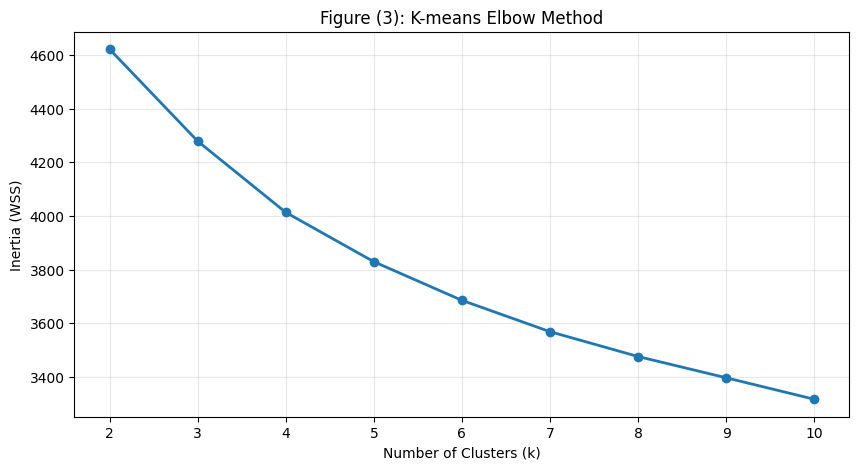

In [295]:
# Range of k values to test
k_range = range(2, 11)

# Store inertia (Within-Cluster Sum of Squares)
inertia = []

# Fit KMeans for each k and collect inertia
for k in k_range:
    model = KMeans(
        n_clusters=k,
        n_init=50,
        init='k-means++',
        random_state=42
    ).fit(clustering_data)
    
    inertia.append(model.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o', linestyle='-', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WSS)')
plt.title('Figure (3): K-means Elbow Method')
plt.grid(True, alpha=0.3)
plt.show()

As shown in Figure (3), the Elbow curve exhibits a smooth and gradual decrease in clustering cost as the number of clusters increases, without a distinct point of sharp change in slope. Instead of forming a clear “elbow,” the curve follows a consistent downward trend, indicating that each additional cluster incrementally improves the model without a well-defined point of diminishing returns. This behavior suggests that the data does not contain well-separated groups, but rather exhibits continuous variation between observations. Therefore, relying solely on the Elbow Method is insufficient in this context, and additional validation techniques such as the Silhouette Score and the Davies-Bouldin Index are required to more reliably determine the optimal number of clusters.


#### **ii. Silhouette Score**

Although introduced in Section 3 as an evaluation metric, the Silhouette Score can also be used to determine the optimal number of clusters (k). By evaluating the score across different values of k, the configuration with the highest score is selected, indicating better cluster separation and cohesion.

#### **iii. Davies-Bouldin Index**

Similarly, the Davies-Bouldin Index can be used to guide the selection of the optimal number of clusters. It evaluates the average similarity between clusters, where lower values indicate more compact and well-separated clusters. The optimal k is therefore chosen by minimizing this index.


In [18]:
# Store evaluation metrics
sil_scores = []
db_scores = []

# Compute metrics for each k
for k in k_range:
    model = KMeans(
        n_clusters=k,
        n_init=50,
        init='k-means++',
        random_state=42
    ).fit(clustering_data)
    
    labels = model.labels_
    
    # Silhouette: higher is better
    sil_scores.append(silhouette_score(clustering_data, labels))
    
    # Davies-Bouldin: lower is better
    db_scores.append(davies_bouldin_score(clustering_data, labels))

# Create results table
df_metrics = pd.DataFrame({
    'k': list(k_range),
    'Silhouette Score': sil_scores,
    'Davies-Bouldin': db_scores
})

# Highlight best values:
# Max Silhouette (best separation)
# Min Davies-Bouldin (least overlap)
display(
    df_metrics.head(9).style
    .background_gradient(subset=['Silhouette Score'], cmap='YlGn')
    .background_gradient(subset=['Davies-Bouldin'], cmap='YlOrRd_r') 
    .highlight_max(subset=['Silhouette Score'], color='lightgreen')
    .highlight_min(subset=['Davies-Bouldin'], color='lightgreen')
)

,k,Silhouette Score,Davies-Bouldin
0,2,0.178139,1.953387
1,3,0.127813,2.342360
2,4,0.106149,2.345041
3,5,0.102937,2.255907
4,6,0.098818,2.242694
5,7,0.090978,2.253228
6,8,0.090569,2.317315
7,9,0.088861,2.286075
8,10,0.087534,2.236626


*Table [1]: Silhouette Score & Davies-Bouldin Index for k-means clustering model with different k values*

Based on the evaluation results in in Table (1), the optimal number of clusters was selected by jointly considering the Silhouette Score and the Davies-Bouldin Index. The configuration with k = 2 achieved the highest Silhouette Score (0.178), Indicating relatively better separation and cohesion compared to other values. Additionally, it achieved the lowest Davies-Bouldin Index value (1.953), suggesting reduced overlap and more distinct clusters compared to other k configurations.

Although the Elbow Method was applied, it did not present a clear inflection point, making it insufficient as a standalone criterion. Therefore, greater reliance was placed on these two quantitative metrics, as they provide more direct and complementary insights into clustering quality. Based on their combined interpretation, **k = 2** was selected as the most appropriate number of clusters.

### 2.4 Applying clustering and assigning cluster labels


In [17]:
# Create a copy of the dataset
patient_data = clustering_data.copy()

# Set optimal number of clusters
k_optimal = 2

# Initialize the model
kmeans_final = KMeans(
    n_clusters=k_optimal,
    random_state=42,
    init='k-means++',
    n_init=50
)

# Fit the model and predict cluster labels
clusters = kmeans_final.fit_predict(clustering_data)

# Assign cluster labels to the copied dataset
patient_data['cluster'] = clusters

# Save to CSV
patient_data.to_csv('Dataset/kmeans_clustered_data.csv', index=False)

patient_data.head()

,Age,Sex,RestingBP,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,...,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,Chol_category_Desirable,Chol_category_Borderline High,Chol_category_High,cluster
0,-1.432206,1,0.5,0,1.383339,0,-0.400000,0,1,0,...,0,1,0,0,0,1,0,0,1,1
1,-0.478057,0,1.5,0,0.754736,0,0.266667,0,0,1,...,0,1,0,0,1,0,1,0,0,1
2,-1.750256,1,0.0,0,-1.523953,0,-0.400000,0,1,0,...,0,0,1,0,0,1,0,0,1,1
3,-0.584074,0,0.4,0,-1.131075,1,0.600000,1,0,0,...,0,1,0,0,1,0,0,1,0,0
4,0.052026,1,1.0,0,-0.581047,0,-0.400000,0,0,1,...,0,1,0,0,0,1,1,0,0,0


---

## Section 3. Evaluation Metrics & Visualizations

### 3.1 Evaluation Metrics

Having defined the evaluation metrics earlier in this section outline, a subset of the most suitable metrics is selected based on the clustering approach. Since k-means is a centroid-based method, WCSS, Silhouette Score, and Davies-Bouldin Index are used as they align with this paradigm by evaluating cluster compactness, separation, and centroid-based structure. In addition, B-Cubed Precision and Recall are employed since ground truth labels are available, allowing the clustering results to be evaluated from a classification perspective. This is especially relevant in our case, where the data can be interpreted as belonging to two underlying classes, enabling a more meaningful assessment of how well the clusters align with the actual labels.

In [18]:
# Using our final model labels
labels = clusters

# Compute metrics
silhouette = silhouette_score(clustering_data, labels)
db_index = davies_bouldin_score(clustering_data, labels)
wcss = kmeans_final.inertia_

# Create a single-row table
evaluation_df = pd.DataFrame([{
    'k': 2,
    'Silhouette Score': f"{silhouette:.3f}",
    'Davies-Bouldin Index': f"{db_index:.3f}",
    'WCSS': f"{wcss:.3f}"
}])

# Save to CSV
evaluation_df.to_csv('Unsupervised_Learning/clustering_results/evaluations/k-means_metrics.csv', index=False)

# Display
evaluation_df


,k,Silhouette Score,Davies-Bouldin Index,WCSS
0,2,0.178,1.953,4621.084


*Table [2]: Evaluation metrics for the k-means clustering model (k = 2), including Silhouette Score, Davies–Bouldin Index, and WCSS.*

**The Silhouette Score** (0.178), being close to zero, indicates weak cluster separation and significant overlap between data points. This confirms that the dataset does not exhibit a strong clustering structure, which is consistent with the earlier clusterability analysis.

**The Davies–Bouldin Index** (1.953) further supports this observation, as higher values indicate less compact and poorly separated clusters. This suggests that many data points lie near cluster boundaries and share similarities with neighboring clusters.

**The Within-Cluster Sum of Squares (WCSS)** (4621.084) represents the total variance within clusters. Although WCSS is not meaningful in isolation, it is useful for comparing different values of k. The selected k yields a relatively lower WCSS compared to other configurations, suggesting a better trade-off between compactness and model complexity. However, this does not necessarily indicate strong clustering, as other metrics still reflect weak separation.

Despite these results indicating weak clustering performance, clustering is maintained in this study for exploratory and educational purposes. It provides insight into how clustering algorithms behave when applied to data with limited inherent structure.  Medical datasets often exhibit overlapping patient characteristics and continuous variation in clinical features, making it difficult to form clearly separated clusters. In such contexts, clustering is commonly used to identify approximate patient groupings or phenotypes rather than strictly separable classes. Prior studies have shown that clinically meaningful clusters can still be identified despite overlap and weak separation. For example, Ahlqvist et al. (2018) identified distinct diabetes subtypes, while Seymour et al. (2019) demonstrated clinically relevant sepsis phenotypes using clustering approaches. Shah et al. (2015) further showed how clustering can reveal meaningful patterns in complex cardiovascular data. These findings suggest that clustering results in medical contexts should be interpreted as approximate groupings that support exploratory analysis and risk stratification, rather than definitive groupings.

> Ahlqvist, E., Storm, P., Käräjämäki, A., et al. (2018).  
   *Novel subgroups of adult-onset diabetes and their association with outcomes: a data-driven cluster analysis.*  
   The Lancet Diabetes & Endocrinology, 6(5), 361–369.  
   https://doi.org/10.1016/S2213-8587(18)30051-2  
>
> Seymour, C. W., Kennedy, J. N., Wang, S., et al. (2019).  
   *Derivation, validation, and potential treatment implications of novel clinical phenotypes for sepsis.*  
   JAMA, 321(20), 2003–2017.  
   https://doi.org/10.1001/jama.2019.5791  
>
> Shah, S. J., Katz, D. H., Selvaraj, S., et al. (2015).  
   *Phenomapping for novel classification of heart failure with preserved ejection fraction.*  
   Circulation, 131(3), 269–279.  
   https://doi.org/10.1161/CIRCULATIONAHA.114.010637  

In [ ]:
# Get labels from your original dataset
# original_data = the full dataframe
# "HeartDisease" = ground truth column (No HeartDisease= 0 / HeartDisease =  1)

Original_labels = original_data["HeartDisease"].values

# B-Cubed function
def bcubed_precision_recall(Original_labels, labels):

    Original_labels = np.array(Original_labels)
    labels = np.array(labels)

    n = len(Original_labels)

    total_precision = 0
    total_recall = 0

    for i in range(n):

        # This point's true label (its "original family")
        current_label = Original_labels[i]

        # This point's assigned cluster
        current_cluster = labels[i]

        # Find all points in the same cluster
        same_cluster = (labels == current_cluster)

        # Find all points with the same true label
        same_label = (Original_labels == current_label)

        # Points that are BOTH same cluster AND same label
        intersection = np.sum(same_cluster & same_label)

        # Precision: how pure is my cluster?
        precision_i = intersection / np.sum(same_cluster)

        # Recall: how much of my true group was captured?
        recall_i = intersection / np.sum(same_label)

        total_precision += precision_i
        total_recall += recall_i

    # Average over all points
    bcubed_precision = total_precision / n
    bcubed_recall = total_recall / n

    return bcubed_precision, bcubed_recall

precision, recall = bcubed_precision_recall(Original_labels, labels)

# Round to 3 decimal places
precision_rounded = round(precision, 3)
recall_rounded = round(recall, 3)

# Create table
results_df = pd.DataFrame({
    "Metric": ["B-Cubed Precision", "B-Cubed Recall"],
    "Value": [precision_rounded, recall_rounded]
})

# Display table
display(results_df)

# Save to CSV
results_df.to_csv("Unsupervised_Learning/clustering_results/evaluations/K-means_bcubed_precision_recall.csv", index=False)

,Metric,Value
0,B-Cubed Precision,0.646
1,B-Cubed Recall,0.643


*Table [3]: B-Cubed Precision & Recall for the k-means clustering model (k = 2).*

The **B-Cubed Precision score** shown in Table (3), with a value of 0.646, indicates limited cluster purity. This means that, on average, approximately 64.6% of the data points grouped within the same cluster share the same true label (i.e., either having heart disease or not), while a substantial portion remains incorrectly grouped. Similarly, the **B-Cubed Recall score** of 0.643 reflects a limited ability to group together data points that belong to the same true class. Specifically, it indicates that around 64.3% of instances with the same ground truth label are successfully assigned to the same cluster, while a considerable number are separated into other clusters.

Overall, the B-Cubed scores indicate weak to moderate clustering performance, leaning toward weak alignment with the true class distribution. This is because B-Cubed evaluates clustering with respect to label agreement, capturing partial correctness even when clusters are not well separated. This interpretation is further supported by the Silhouette Score (0.178) and the Davies–Bouldin Index (1.953), both of which evaluate the geometric structure of the clusters. The low Silhouette score indicates poor separation between clusters, while the high Davies–Bouldin index reflects low compactness and high similarity among clusters in the feature space. This highlights that while the clustering model achieves some degree of label consistency, the overall cluster structure remains weak and not well-defined.


### 3.2 Visualizations



#### **i. Principal Component Analysis (PCA)**


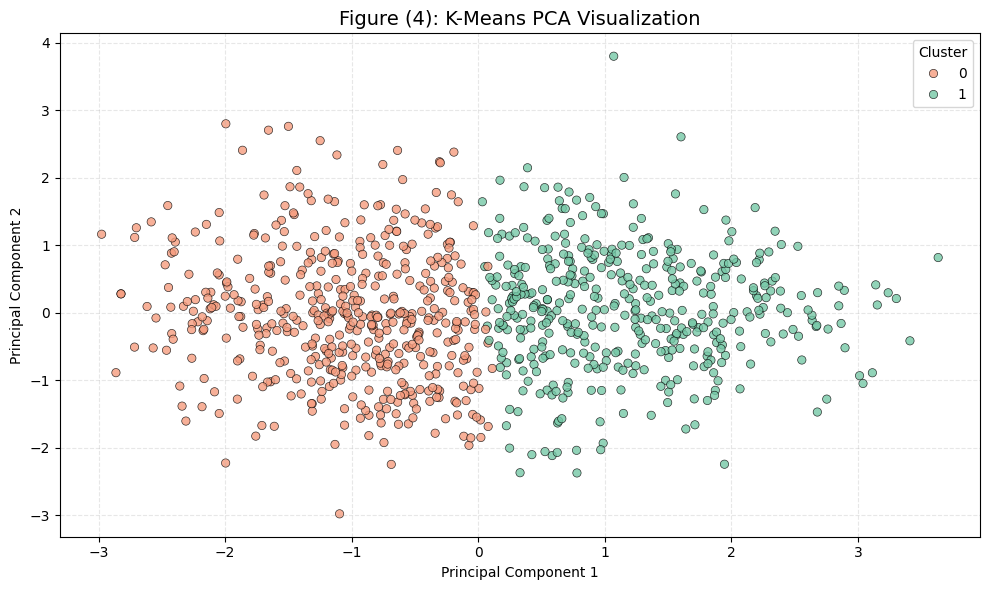

In [299]:
# PCA Transformation
pca = PCA(
    n_components=2,  # Reduce to 2 components for visualization
    random_state=42  # Ensure reproducibility
)

pca_components = pca.fit_transform(clustering_data)

# Store temporarily for plotting
plot_df = patient_data.copy()
plot_df['pca_1'] = pca_components[:, 0]
plot_df['pca_2'] = pca_components[:, 1]

# Plot
plt.figure(figsize=(10, 6))


# Colors
color_map = {
    0: "#f69c7e",   
    1: "#76c8a7",  
}

sns.scatterplot(
    x='pca_1',
    y='pca_2',
    hue='cluster',
    data=plot_df,
    palette=color_map,
    edgecolor='black',
    alpha=0.8
)

plt.title('Figure (4): K-Means PCA Visualization', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

Figure (4) shows a PCA projection of the dataset onto the first two principal components, where a noticeable directional separation appears between the clusters along the first principal component. However, this apparent separation can be misleading. This is because PCA is a dimensionality reduction technique that projects high-dimensional data onto a lower-dimensional space while preserving maximum variance, not cluster separability. As a result, some degree of visual separation may appear in the projection even when the original data is not well clustered.

This explains why, despite the visual distinction in the PCA plot, the clustering evaluation metrics indicate weak performance. The low Silhouette Score (0.178) and high Davies–Bouldin Index (1.953) confirm that the clusters are not well separated in the full feature space. Similarly, the B-Cubed Precision and Recall scores (≈ 0.64) indicate only limited alignment with the true labels. Therefore, the PCA visualization reflects a simplified global structure, whereas the evaluation metrics provide a more accurate assessment of the actual clustering quality.

#### **ii. T-distributed Stochastic Neighbor Embedding (t-SNE)** 

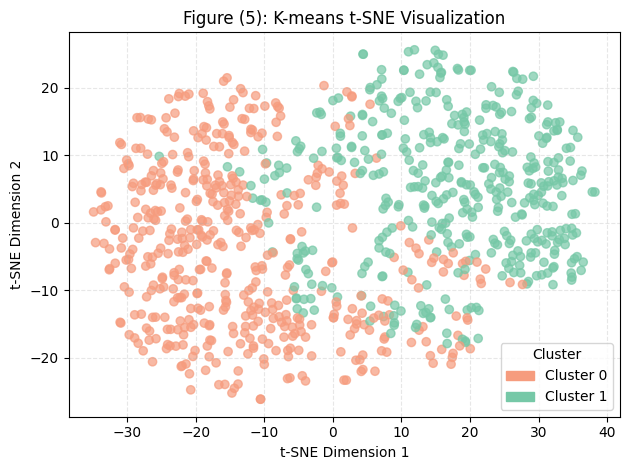

In [300]:
tsne = TSNE(
    n_components=2,          # Better for binary-heavy data visualization
    perplexity=40,           # Balanced for ~900 samples
    learning_rate='auto',    # Keeps the optimization stable
    max_iter=1000,           # Number of optimization iterations (ensures convergence)
    random_state=42          # Ensure reproducibility
)

X_tsne = tsne.fit_transform(clustering_data)

# Using existing color_map 
colors = [color_map[c] for c in clusters]

# Plot
plt.figure()
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, alpha=0.7)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("Figure (5): K-means t-SNE Visualization")

# Legend (reuse color_map)
handles = [
    mpatches.Patch(color=color_map[i], label=f'Cluster {i}')
    for i in sorted(color_map.keys())
]

plt.legend(handles=handles, title="Cluster")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

As shown in Figure (5), Cluster 1 exhibits a noticeable degree of overlap with Cluster 0, with many of its data points extending into regions dominated by Cluster 0. This indicates the presence of shared patterns between the two groups, where patients assigned to different clusters exhibit similar feature profiles.

Such overlap suggests that there is no clear boundary between disease and non-disease cases, reflecting the inherent complexity of medical data. In particular, it highlights that certain patients may display characteristics of both groups, leading to ambiguity in cluster assignment. This observation helps explain the B-Cubed Precision and Recall scores (≈ 0.64), which indicate weak to moderate performance, leaning toward weak. The overlap between clusters increases the likelihood of incorrect assignments, resulting in mixed labels within clusters and incomplete grouping of similar instances. This is further supported by the low Silhouette Score (≈ 0.178), which indicates poor separation between clusters and confirms that the boundaries between groups are not well-defined.

### 3.3 Feature Importance Per Cluster

#### **i. Standardized centroid deviation**

To interpret the clusters generated by K-Means, a centroid-based approach was adopted, using standardized centroid deviation, where the difference between each cluster centroid and the global dataset mean was normalized by the feature’s standard deviation. This provides a scale-independent measure of how strongly each feature differentiates a cluster from the overall data distribution. Since each centroid represents the mean profile of its cluster (MacQueen, 1967), features with larger standardized deviations indicate stronger contribution to defining the cluster. These features correspond to dimensions along which the cluster is most distinct relative to the dataset. This provides a fully unsupervised and interpretable method for estimating feature importance, as it relies directly on centroid representations without requiring external models.

> https://medium.com/%40a.cervantes2012/interpreting-and-validating-clustering-results-with-k-means-e98227183a4d?utm_source=chatgpt.com "Interpreting and Validating Clustering Results with K-Means"


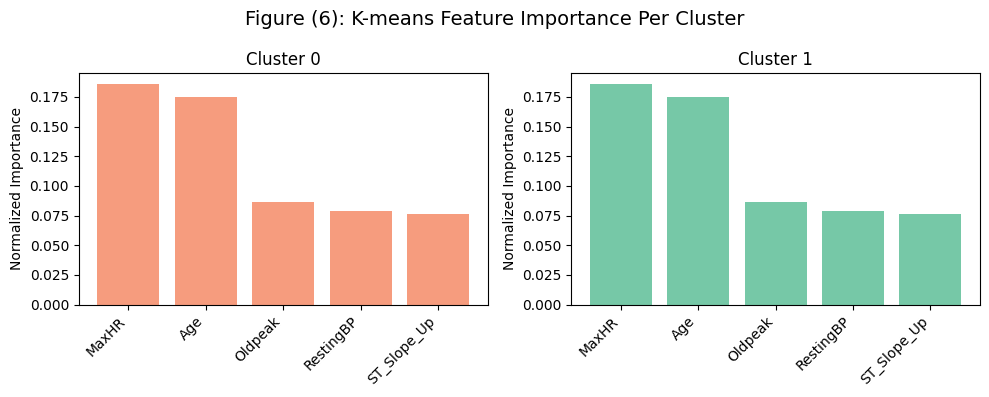

In [301]:
# Centroid-Based Feature Importance (Normalized Deviation)
# Convert dataset to NumPy array for numerical operations
X_values = clustering_data.values

# Extract final cluster centroids from the trained K-Means model
final_centroids = kmeans_final.cluster_centers_

# Compute the global mean of the dataset (reference point)
global_mean = np.mean(X_values, axis=0)

# Compute absolute deviation of each centroid from the global mean
# This measures how much each cluster differs from the overall dataset per feature
abs_movement = np.abs(final_centroids - global_mean)

# Get feature names (handles both DataFrame and NumPy cases)
feature_names = clustering_data.columns if hasattr(clustering_data, "columns") else [f"Feature {i}" for i in range(clustering_data.shape[1])]

# Dictionary to store feature importance per cluster
feature_importance = {}

# Loop over each cluster
for i in range(k_optimal):
    # Get deviation values for current cluster
    vals = abs_movement[i]
    
    # Normalize values so they sum to 1 (relative importance)
    vals_norm = vals / vals.sum()
    
    # Sort features by importance (descending order)
    sorted_idx = np.argsort(vals_norm)[::-1]

    # Store sorted feature importance as (feature_name, importance_score)
    feature_importance[i] = [
        (feature_names[j], vals_norm[j]) for j in sorted_idx
    ]

k = k_optimal # Number of clusters
top_n = 5 # Number of top features to display per cluster

# Create subplots (1 row, k columns)
fig, axes = plt.subplots(1, k, figsize=(5*k, 4))
warnings.filterwarnings("ignore")

# Plot each cluster in its subplot
for i, ax in enumerate(axes):
    features, values = zip(*feature_importance[i][:top_n])
    
    ax.bar(features, values, color=color_map.get(i))
    ax.set_title(f"Cluster {i}")
    ax.set_xticklabels(features, rotation=45, ha='right')
    ax.set_ylabel("Normalized Importance")


fig.suptitle("Figure (6): K-means Feature Importance Per Cluster", fontsize=14)

plt.tight_layout()
plt.show()

As shown in Figure (6), the most consistently influential features across both clusters are MaxHR, Age, Oldpeak, ST_Slope, and RestingBP, as they repeatedly appear among the top-ranked variables. This indicates that these features form the core dimensions along which the clusters are differentiated.


 **Cluster 0** is primarily characterized by MaxHR and Age, indicating that variations in maximum heart rate and age play a major role in defining this group. Additional contributions from Oldpeak, ST_Slope, and RestingBP suggest that multiple cardiovascular indicators collectively shape the cluster profile.

 **Cluster 1** is influenced by a very similar set of features, particularly MaxHR and Age, with secondary contributions from Oldpeak, ST_Slope, and RestingBP. The similarity in feature importance across both clusters indicates that the distinction between them is not based on different variables, but rather on differences in the values of these shared features.

Overall, the dominance of MaxHR, Age, Oldpeak, and RestingBP suggests that the clustering structure is primarily driven by continuous physiological variables. The similarity in feature importance across clusters further indicates that the dataset does not contain entirely distinct subgroups defined by different attributes, but rather reflects gradual variation along the same key clinical dimensions. This is consistent with the weak but observable clustering structure identified earlier

### 3.4 Cluster size distribution

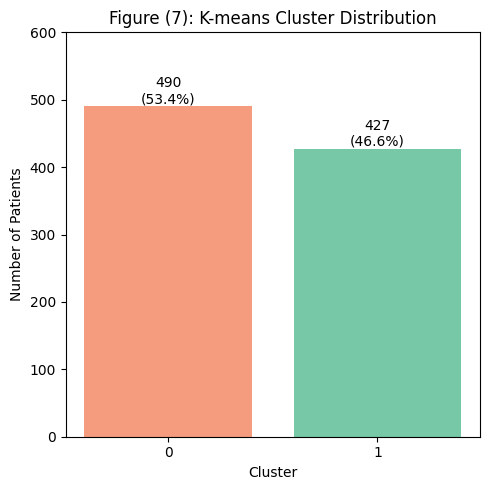

In [302]:
# Count samples per cluster
cluster_counts = patient_data['cluster'].value_counts().sort_index()

# Total samples
total = len(patient_data)

# Using our predefined color_map
colors = [color_map[i] for i in cluster_counts.index]

# Plot
plt.figure(figsize=(5, 5))
bars = plt.bar(cluster_counts.index, cluster_counts.values, color=colors)

# Titles and labels
plt.title('Figure (7): K-means Cluster Distribution')
plt.xlabel('Cluster')
plt.ylabel('Number of Patients')
plt.ylim(0, 600)

# Add values and percentages on bars
for i, count in enumerate(cluster_counts.values):
    percentage = (count / total) * 100
    plt.text(i, count, f'{count}\n({percentage:.1f}%)',
             ha='center', va='bottom')

plt.xticks(cluster_counts.index)
plt.tight_layout()
plt.show()


The cluster distribution shown in Figure (7) reveals a relatively balanced split between the two clusters, with approximately 46% and 53% of the samples assigned to Cluster 0 and Cluster 1, respectively. This distribution is similar to the original class proportions in the dataset.However, this similarity in proportions does not necessarily indicate that the clustering model has accurately captured the true underlying structure. Since clustering was performed in an unsupervised manner, matching class ratios can occur even when individual data points are not correctly grouped. Therefore, while the distribution appears consistent at a global level, the evaluation metrics suggest that the clustering quality remains weak, with limited alignment between cluster assignments and the true labels. This indicates that the clusters may reflect general data balance rather than precise or reliable grouping of patients.

---

## Section 4. Cluster Interpretation & Profiles



### 4.1 Cluster Profiles

Cluster profiling is the process of translating the mathematical centers (centroids) of each group into descriptive human personas. By analyzing the mean values of features within each segment, we can identify the specific personality of a cluster determining which traits are dominant, which are rare, and how each group deviates from the population average. This step moves beyond simple grouping to explain the clinical and demographic logic behind why these specific individuals were clustered together, transforming raw data into identifiable segments. For continuous variables, the cluster means are interpreted relative to the dataset average, allowing us to describe whether a feature is higher or lower compared to the general population. In contrast, for binary (0/1) encoded variables, the mean directly represents the proportion of individuals within the cluster exhibiting that characteristic, enabling interpretation in terms of percentages.

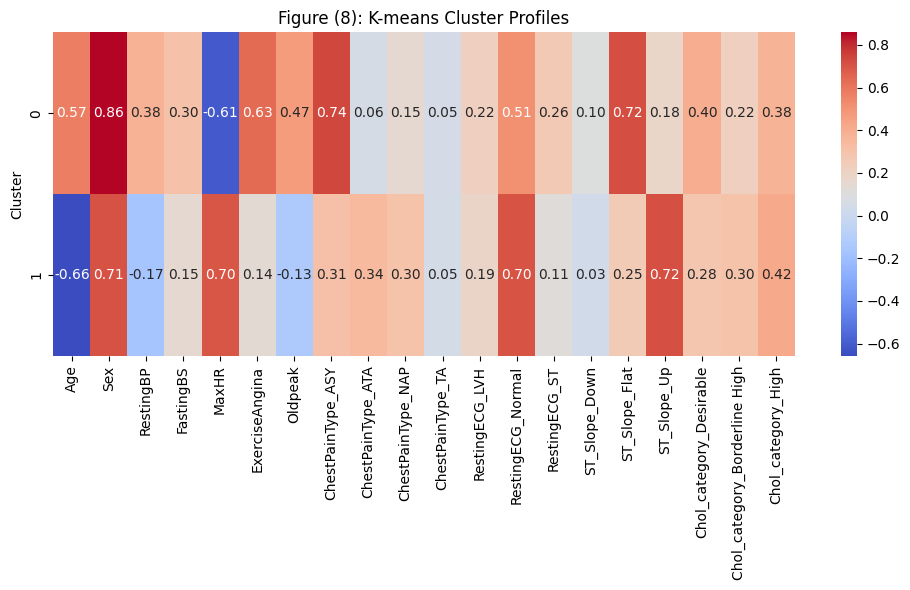

In [303]:
# Compute mean values of features for each cluster
cluster_profiles = patient_data.groupby('cluster').mean()

# Display the profiles
cluster_profiles

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profiles, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Figure (8): K-means Cluster Profiles")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

#### **Cluster 0 Interpretation: High Cardiovascular Risk Profile**

Cluster 0 represents a group of relatively older individuals, with an average age above the dataset mean (53 years). This cluster is predominantly male, with approximately 86% males and only 13% females. However, this imbalance is influenced by the dataset’s overall gender distribution, where nearly 79% of the individuals are male. Therefore, the male dominance in this cluster is heavily influenced by the dataset distribution.

In terms of resting blood pressure (RestingBP), individuals in this cluster exhibit values higher than the dataset average (above 132), suggesting a tendency toward elevated blood pressure levels. Clinically, higher resting blood pressure is associated with increased cardiovascular strain and is considered a known risk factor for hypertension and coronary artery disease. Regarding fasting blood sugar (FastingBS), only 30% of individuals have values above 120, indicating that the majority maintain normal glucose levels. This suggests that, while blood pressure may contribute to cardiovascular risk in this cluster, impaired glucose regulation appears less prominent.

This cluster is also characterized by lower maximum heart rate values (below 136), suggesting reduced cardiovascular performance compared to the dataset average. Additionally, individuals in this cluster show higher Oldpeak values (above 0.88), which represent ST-segment depression during exercise. Elevated Oldpeak values are associated with reduced coronary blood flow and may indicate the presence of coronary artery disease.

Furthermore, 63% of individuals in this cluster exhibit exercise-induced angina (ExerciseAngina), which refers to chest pain triggered by physical exertion due to insufficient blood supply to the heart.

Regarding chest pain types, the dominant category in this cluster is asymptomatic (ASY), with 74% of individuals. This indicates that a large proportion of patients do not experience chest pain despite potential underlying heart disease. This is followed by atypical angina (ATA) at 15%, while non-anginal pain (NAP) and typical angina (TA) are less represented. This distribution is partially influenced by the dataset proportions, where NAP and TA are less frequent overall.

For resting ECG results, 51% of individuals show normal readings. The remaining individuals exhibit abnormalities, including left ventricular hypertrophy (LVH) at 22% and ST-T wave abnormalities (ST) at 26%. These conditions may indicate structural or electrical heart abnormalities, such as myocardial ischemia or chronic hypertension.

In terms of ST slope during exercise, the majority being 72% exhibit a flat slope, which is commonly associated with myocardial ischemia. Only 18% show an upsloping pattern, typically considered normal, while approximately 10% show a downsloping pattern, which may indicate more severe cardiac conditions. The low percentage of downsloping cases may also reflect its low prevalence in the dataset.

Finally, cholesterol levels in this cluster show a mixed distribution across categories. The desirable range represents the largest proportion (40%), followed by the high category (38%), while the borderline group accounts for 22%. This indicates that, although the majority of individuals fall within the normal cholesterol range, a nearly comparable proportion exhibit elevated cholesterol levels. This pattern reflects heterogeneity within the cluster, where individuals share similar overall cardiovascular characteristics but differ in lipid levels. Clinically, this suggests that while the cluster is not uniformly at high lipid risk, a substantial proportion of individuals may still be at increased risk of atherosclerosis and coronary artery disease.

Overall, Cluster 0 can be characterized as a group of older individuals, predominantly male, with higher resting blood pressure and reduced cardiovascular performance, as reflected by lower maximum heart rate values. This cluster also exhibits multiple indicators associated with increased cardiovascular risk, including elevated Oldpeak values, a high prevalence of exercise-induced angina, and predominantly abnormal ST slope patterns, suggesting a higher likelihood of ischemic abnormalities.

#### **Cluster 1 Interpretation: Lower Cardiovascular Risk with Emerging Metabolic Risk**

Cluster 1 represents a group of relatively younger individuals, with an average age below the dataset mean (53 years), but not lower than 27 years. Similar to Cluster 0, this cluster is predominantly male, though slightly less extreme. However, this pattern is influenced by the dataset’s overall male dominance.

In terms of resting blood pressure (RestingBP), individuals in this cluster exhibit values slightly (below 132) compared to the dataset average, suggesting generally normal or mildly lower blood pressure levels. Regarding fasting blood sugar (FastingBS), only a small proportion (around 15%) have elevated levels (>120), indicating that the majority of individuals maintain normal glucose levels.

This cluster is also characterized by higher maximum heart rate values (above 136), indicating better cardiovascular performance compared to the dataset average. Additionally, individuals in this cluster show lower Oldpeak values (below 0.88), reflecting minimal ST-segment depression during exercise. Lower Oldpeak values are typically associated with better coronary blood flow and a reduced likelihood of ischemia.

Furthermore, exercise-induced angina (ExerciseAngina) appears less prominent in this cluster, with only around 14% of individuals experiencing chest pain during physical exertion.

Regarding chest pain types, this cluster shows a partially distributed pattern rather than a fully balanced one. Atypical angina (ATA) represents the highest proportion (34%), followed by asymptomatic cases (31%) and non-anginal pain (30%), which appear at similar levels. In contrast, typical angina (TA) is minimally represented (5%), indicating a clear underrepresentation compared to other categories. This suggests that while most chest pain types are similarly distributed, typical angina is not a defining feature of this cluster. Clinically, chest pain is known to be heterogeneous, where conditions such as coronary artery disease may present as typical, atypical, or even asymptomatic (European Society of Cardiology, 2019). Therefore, the low representation of typical angina alongside higher proportions of atypical and asymptomatic cases suggests that this cluster is not defined by classical symptom presentation, but rather by underlying physiological patterns.

For resting ECG results, normal readings are more prominent in this cluster, with approximately 70% of individuals showing normal ECG patterns, indicating generally healthier cardiac electrical activity. Abnormalities such as left ventricular hypertrophy (LVH) and ST-T wave changes are less pronounced, accounting for approximately 19% and 11%, respectively.

In terms of ST slope during exercise, the upsloping pattern is dominant, observed in approximately 72% of individuals, which is typically considered a normal response. Flat slopes are present but less dominant (around 25%), while downsloping patterns remain minimal. However, this may be partially influenced by the dataset distribution, where downsloping cases are generally less common.

Finally, cholesterol levels in this cluster show a proportional shift toward higher categories. The high cholesterol group represents the largest proportion (42%), followed by the borderline category (30%), while the desirable category accounts for the smallest proportion (28%). This distribution indicates that a greater share of individuals fall within elevated cholesterol ranges. Clinically, this pattern suggests an increased likelihood of lipid-related cardiovascular risk, as a higher proportion of individuals with elevated cholesterol is associated with a greater risk of atherosclerosis and coronary artery disease.

Overall, Cluster 1 can be characterized as a group of younger individuals with better cardiovascular performance, lower Oldpeak values, and generally normal ECG and ST slope patterns, indicating a lower likelihood of ischemic abnormalities. However, despite these favorable cardiac indicators, the distribution of cholesterol levels shows a noticeable shift toward elevated categories. This suggests that, while the cluster is functionally healthier from a cardiovascular perspective, there is an emerging metabolic risk that may contribute to future cardiovascular complications.

> European Society of Cardiology (2019). 2019 ESC Guidelines for the diagnosis and management of chronic coronary syndromes. European Heart Journal. Available at: https://www.escardio.org

### 4.2 Domain Relation

Cluster 0 demonstrates a strong alignment with high cardiovascular risk profiles. The combination of higher Oldpeak values, lower maximum heart rate, and a high proportion of exercise-induced angina , along with predominantly flat ST slope patterns, is clinically associated with myocardial ischemia and reduced coronary blood flow (European Society of Cardiology, 2019). Additionally, the dominance of asymptomatic chest pain suggests the presence of underlying cardiac conditions that may not be immediately apparent through symptoms alone. These findings are consistent with established cardiovascular knowledge, where ST-segment depression, exercise-induced angina, and abnormal ST slope patterns are recognized indicators of coronary artery disease (European Society of Cardiology, 2019).

Within Our Interpretation and Overview System, this cluster could be used to characterize patients exhibiting high-risk-like patterns. The system would present this grouping as a descriptive summary of shared clinical features, allowing users to better understand how certain combinations of variables are associated with elevated cardiovascular risk, without providing explicit recommendations.

In contrast, Cluster 1 reflects a comparatively lower cardiovascular risk profile. This cluster is characterized by higher maximum heart rate, lower Oldpeak values, and a predominance of normal ST slope patterns, which are typically associated with a normal cardiac response to exercise (European Society of Cardiology, 2019). Furthermore, the lower proportion of exercise-induced angina supports the interpretation of better cardiovascular function. However, the higher proportion of individuals with elevated cholesterol levels (42% in the high category) suggests a potential underlying metabolic risk that may contribute to future cardiovascular complications.

Within the same system, this cluster could be presented as representing relatively lower-risk patterns, while still highlighting specific factors, such as elevated cholesterol, that may be relevant for understanding patient profiles. In this way, the system contributes to organizing and interpreting patient data rather than making clinical decisions.

> European Society of Cardiology (2019). 2019 ESC Guidelines for the diagnosis and management of chronic coronary syndromes. European Heart Journal. Available at: https://www.escardio.org

--- 



## Section 5. Integration Feasibility and Justification



While K-means clustering was explored and implemented, it was not selected for integration into the Interpretation and Overview System. This is primarily because the supervised learning approach adopted in Phase 1 provided more reliable and interpretable outputs, which are essential for structuring and understanding patient data. In contrast, the clustering results showed weak separation between groups and significant overlap in patient characteristics (as discussed in Section 4), making them less suitable for clearly distinguishing between patient profiles.



----


## Section 6. Challenges & Limitations



The application of k-means clustering to the heart disease dataset revealed three key challenges. 
First, as illustrated in Figure 3, determining the optimal number of clusters (k) was ambiguous, as the elbow point was not clearly identifiable. This introduced uncertainty into the model selection process. Second, the dataset exhibited significant overlap in patient characteristics, reflecting the continuous nature of cardiovascular risk. This resulted in weak separation between clusters, as observed in the visualizations using Principal Component Analysis (PCA) and t-distributed Stochastic Neighbor Embedding (t-SNE) in Figures 4 and 5. Third, interpreting the resulting cluster profiles posed a challenge, as translating statistical feature averages into meaningful medical insights required additional domain understanding and research.

In addition, these observations highlight a broader limitation related to data suitability for clustering. When a dataset does not exhibit clear separability, clustering techniques may not yield well-defined groups. This underscores the importance of evaluating alternative datasets or feature representations when clustering performance is limited. In this work, the dataset was primarily used for exploratory and educational purposes, which provided valuable insights into both the capabilities and limitations of clustering methods when applied to real-world clinical data.
Together, these challenges emphasize both the methodological limitations of k-means and the inherent complexity of real-world medical datasets, suggesting that future work may benefit from alternative clustering approaches or enhanced feature engineering techniques.

---

## **Cluatering Model 2: HDBSCAN**

## Section 1. Clustering Rationale & Algorithm Selection

### **What is HDBSCAN Algorithm?**

HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) is a clustering algorithm that builds a hierarchy of clusters based on density. It is an extension of the DBSCAN method, which is a density-based clustering method. However, DBSCAN struggles with the assumption of global density, meaning it uses the same density threshold for all clusters. This often does not comply with medical datasets or many real world datasets in general , where clusters may have varying densities and sizes. Unlike DBSCAN, HDBSCAN can identify these variations effectively.

One of the most interesting features of the HDBSCAN algorithm is its ability to decide the optimal number of clusters while remaining robust to noise and outliers. These outliers are prevalent in our medical dataset and cannot be ignored, as they may represent significant clinical cases. This process of selecting the appropriate number of clusters is handled systematically by examining cluster stability across various density thresholds.


### **How does it work?**

The HDBSCAN algorithm consist of two phases:

- ***Mutual Reachability Graph***\
The algorithm starts by computing the core distance $d_c$ for all points. This represents the distance between a point $x_p$ and its $n$-th nearest neighbor $x_{s}, where $n$ is defined by the `min_samples` parameter. The smaller core distance the more points near to it the more density spot the point in. It calculated by the following formula:  $$d_c(x_p) = d(x_p, x_s)$$\
Then it calculates the mutual reachability distance $d_m$ between every pair points using the following formula: $$d_m(x_p, x_q) = \max \{d_c(x_p), d_c(x_q), d(x_p, x_q)\}$$ By taking the maximum, the algorithm effectively spreads out points that are in sparse regions.Thus, even if two points are close to each other. if one of them is in a low-density spot (large $d_c$), the mutual reachability distance between them will be larger. This gives a small distance between points that are both close to each other and located in high-density regions.\
After the computing mutual reachability distances, the algorithm builds the mutual reachability graph $G_{ms}$, where each data point represented as a vertex, and the edges between points represent the mutual reachability distance between them.

- ***Hierarchical Clustering***\
As we mentioned before, the HDBSCAN finds the appropriate number of clusters by examining clusters stability across various density thresholds **$\epsilon$**. This gives all connected parts for all **$\epsilon$** values. This done as the following:
1. Extracting a minimum spanning tree (MST) of $G_{ms}$, that is the subset of edges that connects all vertices together, without any cycles, and with the minimum possible total edge weight.
2. Adding a "self edge" for each vertex on the MST with a weight equals to its core distance.
3. Create a single cluster that contains the whole MST.
4. Finding the edges with the greatest weight (core distance) and remove them to splits the vertex groups connected with a weak edge, generating two **connected components**.
5. Labeling the connected components (clusters).
    1. If a connected component contains only one vertex (no edge) or less than `min_cluster_size` parameter if specified, label it as null (noise).
    2. If a connected component contains more than one vertex label it as a new cluster.
6. Repeat 4-5 until there are no more connected components (clusters become stable).

### **Why is HDBSCAN suitable for our data?**

#### i. Dataset size & feature types

The HDBSCAN algorithm affected by high-dimensional spaces (50-100 features) and can result in curse of dimensionality unless dimensionality reduction techniques applied [-], however our dataset were shrink after performing multiple experiments by researchers to includes only the top 20 important features as their consequences (other illnesses) affects the heart disease [-]. Consequently, dimensionality is not a concern, as 20 features does not considered high-dimensional and as our sample size ($N = 917$) exceeds the recommended 10–20 times the number of features.

It is also capable of handling mixed data types including both continuos and categorical features as long as the categorical features are appropriately preprocessed (e.g., One-Hot Encoding for nominal data and Label Encoding for ordinal data). Our preprocessing pipeline has already addressed these requirements, making HDBSCAN suited for our dataset.

The HDBSCAN algorithm considered a good choice for complex datasets like our medical dataset, as it is able to handle sparse clusters with varying shapes and densities of patients. These variations results from the various combinations of features that leads to herat disease and other diseases that can result from those combinations and cause a heart disease, some of those caused combinations have a high density ( combinations associated with high occurrence heart disease cause like Diabetes) others can have low density ( unpopular heart disease causes and conditions), the HDBSCAN can handle this density variation problem and not only specify a single density threshold.

---

#### ii. Expected cluster shapes

---

#### iii. Scalability & interpretability

- **Scalability** \
In the theoretical explanation of HDBSCAN algorithm, the process of finding the nth-nearest neighbor (used to computed the core distance) is expensive with a time complexity of O($n_2$), since it compute the distances between all pairs of points. However, the implementation can be optimize to approximately O(n log n) using KD-trees for low-dimensional data (less than 20). As the dimensionality increases, the efficiency of KD-trees degrades due to the Curse of Dimensionality, and alternatives such as Ball Trees are used, although performance still worsens with higher dimensions. \
\
 Another theoretical complexity is building a graph that contains all edges ( based on mutual reachability distances), it take O($n_2$) as every vertex should be connected to every other vertexes. To optimize this, the algorithm use MST tree (Minimum Spanning Tree ) that contains the minimum set of edges that dropping any edge results in disconnected components (no cycles), and this set of edges should contains the minimum total wights. \
 \
  To further improve efficiency, the MST is not built over the full graph, but instead it built over a k-nearest neighbor graph, significantly reducing the number of edges. Additionally, the implementation uses Borůvka's algorithm (or its optimized variants), which has a time complexity of approximately O(|E| log |V|) in the worst case, where |E| is the number of edges and |V| is the number of vertices. \
  \
  This gives an approximately total time complexity O(n log n) for low-dimensional data which our dataset is around, but it can degrade toward O($n_2$) in high-dimensional spaces.

- **Interpretability**  \
The Interpretability in clustering algorithms defined by the ability to understanding the structure of clusters and their formation. The HDBSCAN algorithm produces a hierarchical structure and identifies noise. This hierarchical organization can facilitate interpretation by allowing users to explore clusters at different levels of granularity. However, it does not provide simple representations such as centroids. \
\
The hierarchical structure of clusters and noise identification is important for our dataset, as it helps in associating different types of patients within a hierarchical framework, which gives a valuable insights into relationships between patient groups at multiple levels, while also identifying outliers that may represent important or unusual medical cases.